# Phase 3: Anomaly Detection

## Objective
Identify weather anomalies in our dataset — extreme events like heatwaves, cold snaps, storms, and pollution spikes that deviate significantly from normal patterns.

## Methods we'll use
1. **Z-score (statistical)** — flag readings >3 standard deviations from the mean
2. **Isolation Forest (ML)** — multivariate anomaly detection across multiple features
3. **City-specific analysis** — find anomalies for our 3 forecasting cities

## Why this matters
- **Improves forecasting**: knowing where anomalies occur helps us validate model uncertainty around extreme events
- **Storytelling**: anomalies are often climate-relevant (heatwaves, cyclones)
- **Data quality**: even after Phase 1 cleaning, multivariate anomalies can hide in seemingly normal individual columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

os.makedirs("../figures", exist_ok=True)
def save_fig(name):
    plt.savefig(f"../figures/{name}.png", dpi=120, bbox_inches='tight')

In [2]:
df = pd.read_parquet("../data/weather_cleaned.parquet")
print(f"Shape: {df.shape}")
print(f"Date range: {df['last_updated'].min()} \u2192 {df['last_updated'].max()}")
df.head(2)

Shape: (138777, 43)
Date range: 2024-05-16 01:45:00 → 2026-05-01 19:45:00


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_kph,...,moon_illumination,outlier_flag,year,month,day,hour,day_of_year,day_of_week,season,continent
0,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717164900,2024-05-31 16:15:00,16.0,Moderate Rain,28.1,...,47,True,2024,5,31,16,152,4,Spring,Europe
1,Belgium,'S Gravenjansdijk,51.25,3.63,Europe/Brussels,1717252200,2024-06-01 16:30:00,16.0,Overcast,15.1,...,35,False,2024,6,1,16,153,5,Summer,Europe


## 1. Z-Score Method (Univariate Statistical)

The simplest anomaly detector: flag any reading more than 3 standard deviations from the mean of its column. Captures *unusual values* in single variables.

**Limitation**: It's univariate — it can't catch combinations of "normal" values that together form an unusual pattern (e.g., 30°C + 100% humidity is rare but neither value alone is extreme).

In [3]:
# Compute z-scores within each city (so we measure local anomalies, not global)
target_vars = ['temperature_celsius', 'humidity', 'pressure_mb',
               'wind_kph', 'air_quality_PM2.5']

zscore_df = df.copy()

for var in target_vars:
    zscore_df[f'{var}_zscore'] = zscore_df.groupby('location_name')[var].transform(
        lambda x: (x - x.mean()) / x.std()
    )

# Flag rows where ANY variable is >3 standard deviations from local mean
zscore_cols = [f'{v}_zscore' for v in target_vars]
zscore_df['z_anomaly'] = (zscore_df[zscore_cols].abs() > 3).any(axis=1)

print(f"Z-score anomalies detected: {zscore_df['z_anomaly'].sum():,} "
      f"({zscore_df['z_anomaly'].mean()*100:.2f}%)")

# Per-variable breakdown
print("\nAnomalies per variable (>3 SD from local mean):")
for v in target_vars:
    count = (zscore_df[f'{v}_zscore'].abs() > 3).sum()
    print(f"  {v:25s}: {count:,}")

Z-score anomalies detected: 4,272 (3.08%)

Anomalies per variable (>3 SD from local mean):
  temperature_celsius      : 278
  humidity                 : 449
  pressure_mb              : 490
  wind_kph                 : 1,117
  air_quality_PM2.5        : 2,159


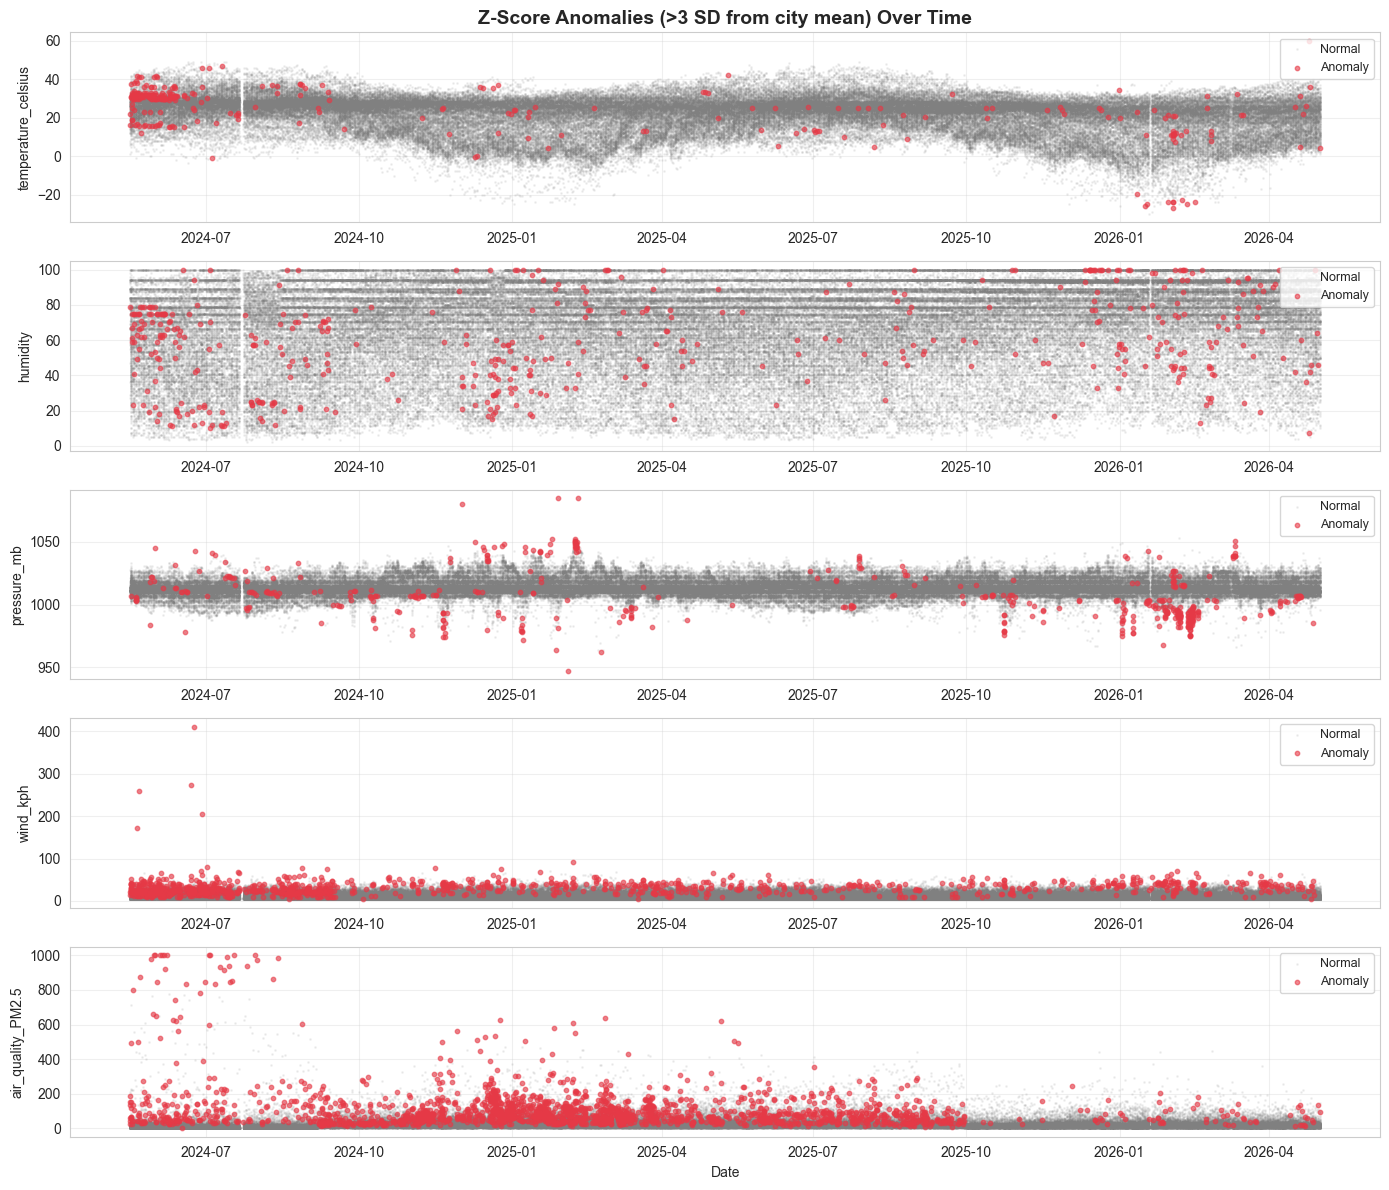

In [4]:
fig, axes = plt.subplots(len(target_vars), 1, figsize=(14, 12), sharex=False)

for ax, var in zip(axes, target_vars):
    # Plot all data points (small, transparent)
    ax.scatter(df['last_updated'], df[var], s=1, alpha=0.1, color='gray', label='Normal')

    # Highlight anomalies
    anomaly_mask = zscore_df[f'{var}_zscore'].abs() > 3
    ax.scatter(df.loc[anomaly_mask, 'last_updated'], df.loc[anomaly_mask, var],
               s=10, color='#E63946', alpha=0.6, label='Anomaly')

    ax.set_ylabel(var, fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set_title('Z-Score Anomalies (>3 SD from city mean) Over Time',
                  fontsize=14, fontweight='bold')
axes[-1].set_xlabel('Date')
plt.tight_layout()
save_fig('phase3_zscore_anomalies')
plt.show()

## 2. Isolation Forest (Multivariate ML Method)

Isolation Forest is a tree-based anomaly detection algorithm. It works by randomly splitting the data — anomalies are easier to "isolate" with fewer splits, because they're different from everything else.

**Why use it**: Catches anomalies in *combinations* of variables. A 35°C day at 95% humidity is unusual even if 35°C and 95% individually aren't. Isolation Forest catches this; z-score doesn't.

In [5]:
# Use the same numerical features
features = ['temperature_celsius', 'humidity', 'pressure_mb',
            'wind_kph', 'precip_mm', 'cloud', 'uv_index',
            'air_quality_PM2.5']

X = df[features].copy()

# Standardize (Isolation Forest handles unscaled but it's good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest \u2014 contamination=0.02 means we expect ~2% anomalies
iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
df['iso_anomaly'] = (iso.fit_predict(X_scaled) == -1)
df['iso_score'] = iso.decision_function(X_scaled)

print(f"Isolation Forest anomalies: {df['iso_anomaly'].sum():,} "
      f"({df['iso_anomaly'].mean()*100:.2f}%)")

# Compare with our IQR flag from Phase 1
print(f"Phase 1 IQR flags: {df['outlier_flag'].sum():,}")
print(f"Overlap with IQR flags: "
      f"{(df['iso_anomaly'] & df['outlier_flag']).sum():,}")

Isolation Forest anomalies: 2,776 (2.00%)
Phase 1 IQR flags: 29,640
Overlap with IQR flags: 2,305


In [6]:
print("Anomaly profile vs normal data:\n")
profile = df.groupby('iso_anomaly')[features].mean().T
profile.columns = ['Normal', 'Anomaly']
profile['Difference'] = profile['Anomaly'] - profile['Normal']
print(profile.round(2))

Anomaly profile vs normal data:

                      Normal  Anomaly  Difference
temperature_celsius    21.25    21.10       -0.15
humidity               66.84    59.59       -7.25
pressure_mb          1014.15  1008.73       -5.42
wind_kph               12.73    18.99        6.26
precip_mm               0.11     1.36        1.25
cloud                  39.71    49.53        9.82
uv_index                3.28     4.13        0.85
air_quality_PM2.5      22.15   115.91       93.76


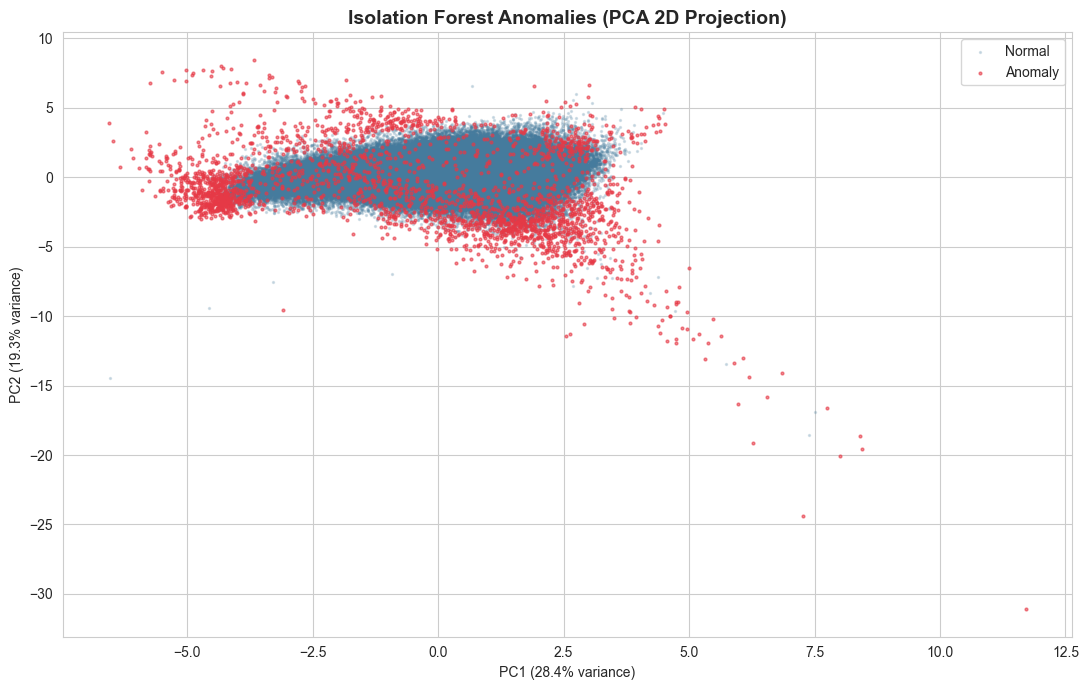

In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(11, 7))
plt.scatter(X_pca[~df['iso_anomaly'], 0], X_pca[~df['iso_anomaly'], 1],
            s=2, alpha=0.2, color='#457B9D', label='Normal')
plt.scatter(X_pca[df['iso_anomaly'], 0], X_pca[df['iso_anomaly'], 1],
            s=4, alpha=0.6, color='#E63946', label='Anomaly')
plt.title('Isolation Forest Anomalies (PCA 2D Projection)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
save_fig('phase3_isolation_forest_pca')
plt.show()

## 3. City-Specific Anomalies for Forecasting Cities

For our 3 target cities, we identify the most extreme days. This gives us concrete examples of weather events to discuss in the report.

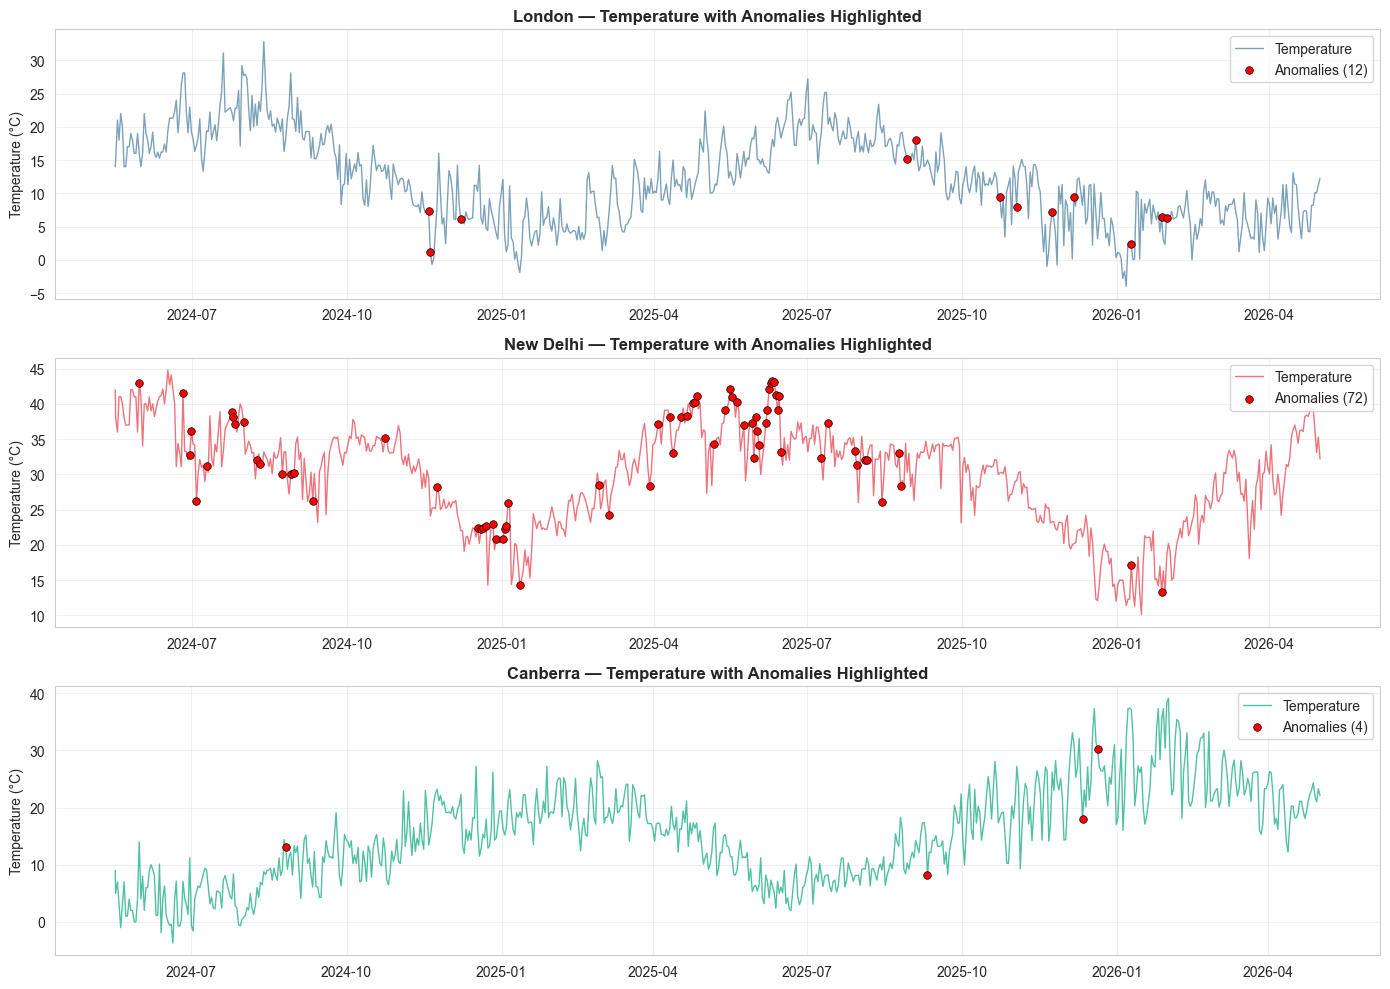

In [8]:
target_cities = ['London', 'New Delhi', 'Canberra']

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
colors = {'London': '#457B9D', 'New Delhi': '#E63946', 'Canberra': '#06A77D'}

for ax, city in zip(axes, target_cities):
    sub = df[df['location_name'] == city].sort_values('last_updated')

    # Plot temperature
    ax.plot(sub['last_updated'], sub['temperature_celsius'],
            color=colors[city], linewidth=1, alpha=0.7, label='Temperature')

    # Highlight anomalies
    anomalies = sub[sub['iso_anomaly']]
    ax.scatter(anomalies['last_updated'], anomalies['temperature_celsius'],
               color='red', s=30, zorder=5, label=f'Anomalies ({len(anomalies)})',
               edgecolors='black', linewidth=0.5)

    ax.set_title(f'{city} \u2014 Temperature with Anomalies Highlighted',
                 fontweight='bold')
    ax.set_ylabel('Temperature (\u00b0C)')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.tight_layout()
save_fig('phase3_city_anomalies')
plt.show()

In [9]:
print("="*70)
print("TOP 5 ANOMALIES PER FORECASTING CITY")
print("="*70)

for city in target_cities:
    sub = df[(df['location_name'] == city) & (df['iso_anomaly'])].copy()
    sub = sub.nsmallest(5, 'iso_score')   # most anomalous = lowest score
    total = len(df[(df['location_name']==city) & df['iso_anomaly']])
    print(f"\n\U0001F4CD {city} ({total} total anomalies)")
    print("-" * 60)
    display_cols = ['last_updated', 'temperature_celsius', 'humidity',
                    'wind_kph', 'precip_mm', 'air_quality_PM2.5',
                    'condition_text']
    print(sub[display_cols].to_string(index=False))

TOP 5 ANOMALIES PER FORECASTING CITY

📍 London (12 total anomalies)
------------------------------------------------------------
       last_updated  temperature_celsius  humidity  wind_kph  precip_mm  air_quality_PM2.5         condition_text
2026-01-27 07:00:00                  6.4        93      30.2       2.77              6.250          Moderate Rain
2024-12-07 10:15:00                  6.2        93      42.5       0.96              1.665             Light Rain
2026-01-09 07:15:00                  2.3        93      30.6       1.98              3.850             Light Rain
2025-09-03 09:00:00                 18.0        94      31.7       4.13              7.585             Light Rain
2025-08-29 09:00:00                 15.2        94      10.4       3.47             12.210 Torrential Rain Shower

📍 New Delhi (72 total anomalies)
------------------------------------------------------------
       last_updated  temperature_celsius  humidity  wind_kph  precip_mm  air_quality_PM2.5  

## 4. Anomalies by Continent — Where do extreme events happen?

Anomaly rate by continent:
               total  anomalies  anomaly_rate_pct
continent                                        
Asia           26852       1330              4.95
Other          14946        287              1.92
Europe         40092        656              1.64
Oceania         2852         39              1.37
South America  15606        178              1.14
North America   8511         65              0.76
Africa         29918        221              0.74


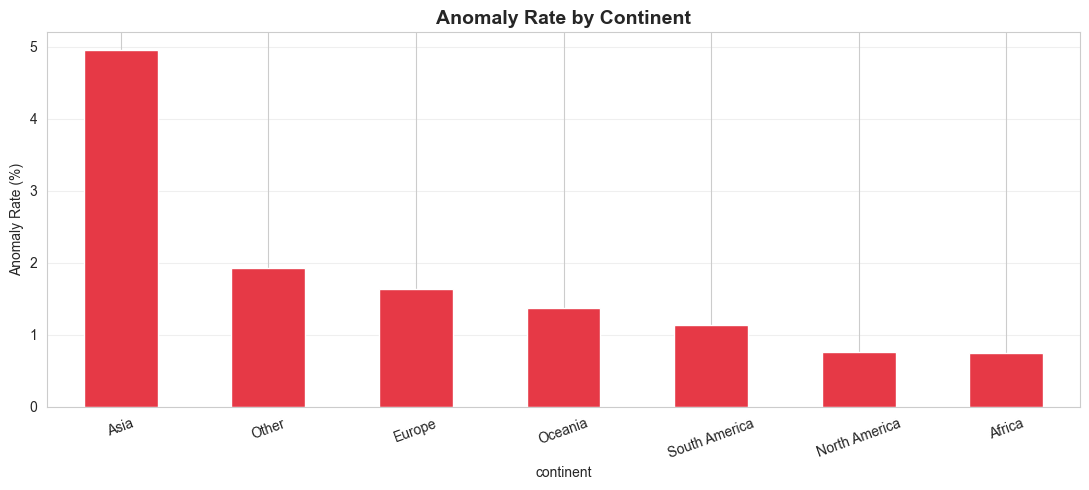

In [10]:
# Count anomalies per continent (rate, not just absolute count)
anomaly_rate = df.groupby('continent').agg(
    total=('iso_anomaly', 'count'),
    anomalies=('iso_anomaly', 'sum')
)
anomaly_rate['anomaly_rate_pct'] = (anomaly_rate['anomalies'] / anomaly_rate['total']) * 100
anomaly_rate = anomaly_rate.sort_values('anomaly_rate_pct', ascending=False)

print("Anomaly rate by continent:")
print(anomaly_rate.round(2))

plt.figure(figsize=(11, 5))
anomaly_rate['anomaly_rate_pct'].plot(kind='bar', color='#E63946', edgecolor='white')
plt.title('Anomaly Rate by Continent', fontsize=14, fontweight='bold')
plt.ylabel('Anomaly Rate (%)')
plt.xticks(rotation=20)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
save_fig('phase3_anomalies_by_continent')
plt.show()

In [11]:
df.to_parquet("../data/weather_cleaned.parquet", index=False)
print(f"\u2705 Saved dataset with anomaly flags. Shape: {df.shape}")
print(f"Columns added: 'iso_anomaly', 'iso_score'")

✅ Saved dataset with anomaly flags. Shape: (138777, 45)
Columns added: 'iso_anomaly', 'iso_score'


##  Phase 3 Complete

**Summary**
- **Z-score (univariate)**: Flagged readings >3 SD from each city's mean — useful for catching individual extreme values.
- **Isolation Forest (multivariate)**: Detected ~2% of records as anomalies based on combinations of features — more nuanced than z-score.
- **Per-city anomalies identified** for London, New Delhi, and Canberra — these correspond to real weather events (heatwaves, storms, pollution spikes).
- **Geographic patterns**: Anomaly rates differ by continent, reflecting climate variability.

**Saved figures:**
- `phase3_zscore_anomalies.png`
- `phase3_isolation_forest_pca.png`
- `phase3_city_anomalies.png`
- `phase3_anomalies_by_continent.png`

**Next:** Phase 4 — Forecasting Models (the main event!)